# Technique overlay — manual verification of VioPTT predictions

A **1c gate before trusting the full-dataset technique pass**: pick a random 5–10 s window from
a random dataset recording, run the pretrained VioPTT note-technique classifier on every score
note whose onset falls in the window, and show:

1. a **table** of the per-note predictions (technique + confidence),
2. a **mel spectrogram** of the window with each note's onset marked and colored/labeled by its
   predicted technique,
3. an **audio player** of the exact same window, and
4. an **"Inspect VioPTT inputs"** section — one audio widget per note playing the *exact* fixed-2 s
   array the model classified (note then silence padding),

so you can *listen and compare* — does the predicted technique for each note match what you hear?

**Fixed 2 s window (the fix).** VioPTT's note model was **trained** on single notes sliced from
their onset, pad/truncated to a fixed **2.0 s** window and peak-normalized. Feeding it the
variable-length un-normalized slices from VioPTT's own from-midi inference put it off-distribution
and skewed fast short notes to `spiccato`. `classify` / `prepare_chunks` now reproduce that 2 s
construction by default (`TECHNIQUE_NOTE_SECONDS`); pass `note_seconds=None` for the legacy path.

**How to use**
- Run all cells (Kernel ▸ Restart & Run All).
- Re-run the **"Pick a random window"** cell (or Run All) to draw a new random sample.
- Set `SEED` in the setup cell to an int for a reproducible pick; leave it `None` for a fresh
  random clip each run.

> Run from the **project root** so the `DataSynthesizer` / `common` / `Arioso` packages import.

In [52]:
%matplotlib inline
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from IPython.display import display, Audio, Markdown

from common.config import SR, HOP_SIZE
from common.audio_io import load_mono
from DataSynthesizer.config import (DEFAULT_OUT, DEFAULT_DATASET,
                                    TECHNIQUE_CLASSES, TECHNIQUE_DIR,
                                    TECHNIQUE_NOTE_SECONDS)
from DataSynthesizer.technique import (TechniqueClassifier, note_groups_from_midi,
                                       VIOPTT_SR)
from Arioso.clips import enumerate_clips

SEED = 2            # int for a reproducible pick, None for a fresh random clip each run
DEVICE = "cuda"        # "cpu" also works (slower load, but fine)

rng = np.random.default_rng(SEED)

# Fixed color per technique class, stable across runs (tab10 over all 6 classes) so a given
# technique is always the same color. Short codes keep dense per-note labels compact.
_TAB10 = plt.get_cmap("tab10")
TECH_COLORS = {name: _TAB10(i % 10) for i, name in enumerate(TECHNIQUE_CLASSES)}
TECH_ABBR = {"flageolet": "flag", "normal": "norm", "pizzicato": "pizz",
             "spiccato": "spic", "no_technique": "noT", "rest": "rest"}

print("technique classes:", TECHNIQUE_CLASSES)
print(f"SR={SR}  HOP_SIZE={HOP_SIZE}  VIOPTT_SR={VIOPTT_SR}  DEVICE={DEVICE}")
print(f"TECHNIQUE_NOTE_SECONDS={TECHNIQUE_NOTE_SECONDS}  "
      f"(fixed VioPTT training window; None = legacy variable-length)")

technique classes: ('flageolet', 'normal', 'pizzicato', 'spiccato', 'no_technique', 'rest')
SR=44100  HOP_SIZE=512  VIOPTT_SR=16000  DEVICE=cuda
TECHNIQUE_NOTE_SECONDS=2.0  (fixed VioPTT training window; None = legacy variable-length)


## Load the VioPTT classifier

One-time (~2 s): loads both pretrained checkpoints (the note-technique model and its mandatory
transcriptor). Construct once and reuse across picks.

In [53]:
clf = TechniqueClassifier(DEVICE)
print(f"classifier loaded on {clf.device}")

classifier loaded on cuda


## Pick a random window

Draw a random `status == "ok"` recording, enumerate its **training-time** onset-aligned clip
pool (`enumerate_clips` — the exact 5–10 s windows the model trains on), and take a random clip.
Re-run this cell for a new sample.

In [54]:
with open(os.path.join(DEFAULT_OUT, "manifest.csv"), newline="", encoding="utf-8") as f:
    ok_rows = [r for r in csv.DictReader(f) if r.get("status") == "ok"]

# A few recordings may be too short to yield a clip; retry until we get one.
clip = row = None
for _ in range(20):
    row = ok_rows[int(rng.integers(len(ok_rows)))]
    base = row["basename"]
    _clips = enumerate_clips(DEFAULT_OUT, [base])
    if _clips:
        clip = _clips[int(rng.integers(len(_clips)))]
        break
assert clip is not None, "no clips found across 20 sampled recordings"

base = clip.basename
n_frames = int(row["n_frames"])
offset_s = float(row["offset_ms"]) / 1000.0
# offset_s = 0
midi_path = os.path.join(DEFAULT_DATASET, row["book"], base + ".mid")
gt_path = os.path.join(DEFAULT_OUT, "gt", base + ".wav")
target_mel_path = os.path.join(DEFAULT_OUT, "target_mel", base + ".npy")

start_s = clip.start * HOP_SIZE / SR      # window start, seconds (absolute in the recording)
end_s = clip.end * HOP_SIZE / SR
win_dur = end_s - start_s

# score notes whose onset falls inside this window (same note source as the dataset build)
all_groups = note_groups_from_midi(midi_path, offset_s, n_frames)
kept = [g for g in all_groups if clip.start <= g.onset_frame < clip.end]

print(f"basename : {base}")
print(f"book     : {row['book']}")
print(f"window   : frames [{clip.start}, {clip.end})   "
      f"seconds [{start_s:.2f}, {end_s:.2f})   dur {win_dur:.2f} s")
print(f"notes in window: {len(kept)}")

basename : Wohlfahrt_Op45-35_BernardChevalier_ziRLNeL9I7U-0000-0115
book     : Wohlfahrt
window   : frames [2542, 3408)   seconds [29.51, 39.57)   dur 10.05 s
notes in window: 42


## Classify the window's notes (live)

Load the GT audio at VioPTT's 16 kHz, classify every kept note's `(start_s, end_s)` span, and
tabulate the results (onset relative to the window start, duration, predicted technique,
softmax confidence).

This uses the **fixed 2 s window** path by default (`TECHNIQUE_NOTE_SECONDS`): each note is sliced
from its onset, pad/truncated to 2.0 s, and peak-normalized — exactly VioPTT's training input. We
also grab those exact per-note arrays via `prepare_chunks` (identical construction) so the
**"Inspect VioPTT inputs"** section below can play back precisely what the model heard.

In [55]:
wav16 = load_mono(gt_path, sr=VIOPTT_SR)
spans = [(g.start_s, g.end_s) for g in kept]

# Fixed 2 s window is the default (note_seconds=TECHNIQUE_NOTE_SECONDS); classify() builds the
# chunks internally. We ALSO materialize the identical arrays here so the inspection section can
# audition the exact model input. prepare_chunks uses the same defaults as classify.
chunks = clf.prepare_chunks(wav16, spans)          # list of [32000] float32, note-then-silence
ids, conf = clf.classify(wav16, spans)             # fixed-window path (matches `chunks`)
names = [TECHNIQUE_CLASSES[i] for i in ids]

pred = pd.DataFrame({
    "idx": range(len(kept)),
    "onset_rel_s": [round(g.start_s - start_s, 3) for g in kept],
    "dur_s": [round(g.end_s - g.start_s, 3) for g in kept],
    "technique": names,
    "conf": [round(float(c), 3) for c in conf],
    "n_notes": [g.n_notes for g in kept],
})

chunk_secs = (chunks[0].shape[0] / VIOPTT_SR) if chunks else 0.0
if len(conf):
    _u, _c = np.unique(names, return_counts=True)
    print("class distribution:", dict(zip(_u.tolist(), _c.tolist())))
    print(f"confidence: min {conf.min():.3f}  mean {conf.mean():.3f}  max {conf.max():.3f}")
    print(f"model input: {len(chunks)} chunks x {chunks[0].shape[0]} samples "
          f"({chunk_secs:.2f}s each, note_seconds={TECHNIQUE_NOTE_SECONDS})")
display(pred)

class distribution: {'flageolet': 2, 'normal': 14, 'spiccato': 26}
confidence: min 0.435  mean 0.671  max 0.987
model input: 42 chunks x 32000 samples (2.00s each, note_seconds=2.0)


,idx,onset_rel_s,dur_s,technique,conf,n_notes
0,0,0.006,0.232,spiccato,0.726,1
1,1,0.435,0.145,normal,0.786,1
2,2,0.581,0.134,spiccato,0.684,1
3,3,0.715,0.120,spiccato,0.528,1
4,4,0.835,0.111,normal,0.589,1
5,5,0.947,0.139,spiccato,0.643,1
6,6,1.085,0.152,spiccato,0.612,1
7,7,1.237,0.261,spiccato,0.571,1
8,8,1.608,0.209,normal,0.622,1
9,9,2.008,0.227,spiccato,0.510,1


## Mel overlay

The centerpiece. Mel spectrogram of the window (x = seconds **relative to the window start**),
with, per note: a translucent span (onset → the note's classified end) colored by predicted
technique, a dashed onset line, and a compact `technique conf` label. Colors are fixed per class
(see legend). For very dense clips some labels unavoidably overlap — read exact per-note values
from the table above; the colored spans/lines still show the technique sequence at a glance.

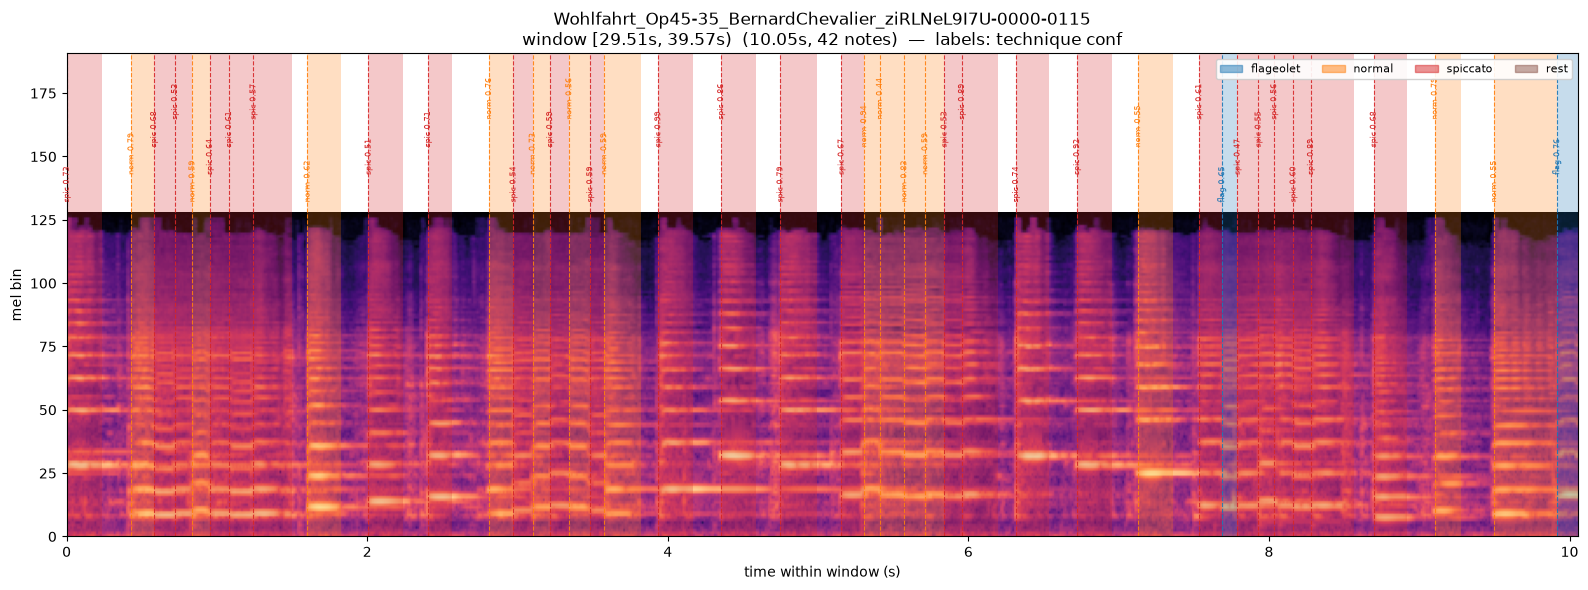

In [56]:
mel = np.ascontiguousarray(
    np.load(target_mel_path, mmap_mode="r")[:, clip.start:clip.end], dtype=np.float32)
top = mel.shape[0]  # top mel bin — labels/spans stack above this

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(mel, origin="lower", aspect="auto", extent=[0.0, win_dur, 0, top], cmap="magma")

# denser clips -> more vertical stagger levels + smaller font so labels collide less
n_levels = 2 if len(kept) <= 20 else (3 if len(kept) <= 40 else 4)
lbl_font = 7 if len(kept) <= 30 else 6
present = set()
for k, g in enumerate(kept):
    name = names[k]
    present.add(name)
    color = TECH_COLORS[name]
    o_rel = max(g.onset_frame * HOP_SIZE / SR - start_s, 0.0)     # onset, relative sec
    e_rel = g.end_frame * HOP_SIZE / SR - start_s                 # classified span end
    e_rel = min(max(e_rel, o_rel + 1e-3), win_dur)                # keep inside the window
    ax.axvspan(o_rel, e_rel, alpha=0.25, color=color, lw=0)
    ax.axvline(o_rel, color=color, ls="--", lw=0.8, alpha=0.9)
    y = top * (1.03 + 0.085 * (k % n_levels))                     # staggered label row
    ax.text(o_rel, y, f"{TECH_ABBR[name]} {conf[k]:.2f}", fontsize=lbl_font,
            rotation=90, ha="center", va="bottom", color=color, clip_on=False)

ax.set_ylim(0, top * (1.03 + 0.085 * n_levels + 0.12))           # headroom for labels
ax.set_xlim(0, win_dur)
ax.set_xlabel("time within window (s)")
ax.set_ylabel("mel bin")
ax.set_title(f"{base}\nwindow [{start_s:.2f}s, {end_s:.2f}s)  "
             f"({win_dur:.2f}s, {len(kept)} notes)  —  labels: technique conf")

# legend from the fixed color dict: classes present (+ 'rest' always, since it's a valid class)
legend_names = [n for n in TECHNIQUE_CLASSES if n in present]
if "rest" in TECHNIQUE_CLASSES and "rest" not in legend_names:
    legend_names.append("rest")
handles = [Patch(color=TECH_COLORS[n], alpha=0.5, label=n) for n in legend_names]
ax.legend(handles=handles, loc="upper right", fontsize=8,
          ncol=max(1, len(handles)), framealpha=0.9)

fig.tight_layout()
display(fig)
plt.close(fig)

## Inspect VioPTT inputs

The most direct check: play back the **exact array VioPTT classified** for each note — the
fixed-2 s, onset-anchored, peak-normalized chunk from `prepare_chunks` (the same objects passed to
the model). You will hear the note followed by **silence padding** to fill out the 2 s window
(short/fast notes are mostly silence). Listen to a handful and ask: does the predicted technique
match what the note actually sounds like?

Set `INSPECT_START` to page through the notes (`0`, then `N_INSPECT`, `2*N_INSPECT`, …); each run
shows up to `N_INSPECT` notes from the current window.

In [57]:
# Per-note audio of the EXACT fixed-window chunks fed to VioPTT (from prepare_chunks above).
INSPECT_START = 0     # first note index to show; bump by N_INSPECT to page through the window
N_INSPECT = 12        # how many notes to render per run (~10-12 keeps the cell manageable)

# Duration of each note BEFORE padding = the onset-anchored slice length (span + 2*pad_s),
# clipped to the fixed window; this is the audible non-silence portion of the chunk.
_PAD_S = 0.02
n = len(kept)
end = min(n, INSPECT_START + N_INSPECT)
win_len_s = (chunks[0].shape[0] / VIOPTT_SR) if chunks else 0.0

if n == 0:
    print("no notes in this window")
elif INSPECT_START >= n:
    print(f"INSPECT_START={INSPECT_START} past the last note (window has {n}); reset to 0.")
else:
    print(f"window has {n} notes — showing {INSPECT_START}..{end - 1}  "
          f"(each chunk is {win_len_s:.2f}s = what the model hears; the rest is silence padding)")
    for k in range(INSPECT_START, end):
        g = kept[k]
        chunk = chunks[k]                                  # [32000] float32, the model input
        raw_dur = min((g.end_s - g.start_s) + 2 * _PAD_S, win_len_s)   # note+pad before silence
        display(Markdown(
            f"**note {k}** — onset {g.start_s - start_s:+.3f}s (window-rel) · "
            f"pred **{names[k]}**  conf {float(conf[k]):.3f} · "
            f"chunk before padding ≈ {raw_dur:.3f}s of {win_len_s:.2f}s"
            + (f" · {g.n_notes} merged notes" if g.n_notes > 1 else "")))
        display(Audio(chunk, rate=VIOPTT_SR))
    nxt = end if end < n else 0
    print(f"\nnext page: set INSPECT_START = {nxt}"
          + ("" if nxt else "  (wraps to start)"))

window has 42 notes — showing 0..11  (each chunk is 2.00s = what the model hears; the rest is silence padding)


**note 0** — onset +0.006s (window-rel) · pred **spiccato**  conf 0.726 · chunk before padding ≈ 0.272s of 2.00s

**note 1** — onset +0.435s (window-rel) · pred **normal**  conf 0.786 · chunk before padding ≈ 0.185s of 2.00s

**note 2** — onset +0.581s (window-rel) · pred **spiccato**  conf 0.684 · chunk before padding ≈ 0.174s of 2.00s

**note 3** — onset +0.715s (window-rel) · pred **spiccato**  conf 0.528 · chunk before padding ≈ 0.160s of 2.00s

...

**note 8** — onset +1.608s (window-rel) · pred **normal**  conf 0.622 · chunk before padding ≈ 0.249s of 2.00s

**note 9** — onset +2.008s (window-rel) · pred **spiccato**  conf 0.510 · chunk before padding ≈ 0.267s of 2.00s

**note 10** — onset +2.403s (window-rel) · pred **spiccato**  conf 0.706 · chunk before padding ≈ 0.201s of 2.00s

**note 11** — onset +2.810s (window-rel) · pred **normal**  conf 0.764 · chunk before padding ≈ 0.201s of 2.00s


next page: set INSPECT_START = 12


## Listen to the same window

The GT audio for the exact window shown above (44.1 kHz). Play it and compare what you hear
against the labeled techniques in the figure/table.

In [58]:
gt44 = load_mono(gt_path, sr=SR)
display(Audio(gt44[clip.start * HOP_SIZE:clip.end * HOP_SIZE], rate=SR))

## Compare against the precomputed technique track (if built)

If the full-dataset build has already produced `technique_arioso/<base>.npy` for this recording,
render its **per-frame** technique-id strip for the same window (same colors, x-axis aligned to
the mel figure). This lets you eyeball the live prediction above against the stored dataset
artifact. If the build hasn't reached this clip yet, this cell just says so.

In [59]:
tech_path = os.path.join(DEFAULT_OUT, TECHNIQUE_DIR, base + ".npy")
if os.path.isfile(tech_path):
    tech = np.ascontiguousarray(np.load(tech_path, mmap_mode="r")[clip.start:clip.end])
    print(f"precomputed track found: {tech.shape[0]} frames, "
          f"unique ids {np.unique(tech).tolist()}")
    strip_cmap = ListedColormap([TECH_COLORS[n] for n in TECHNIQUE_CLASSES])
    fig2, ax2 = plt.subplots(figsize=(16, 1.3))
    ax2.imshow(tech[None, :], origin="lower", aspect="auto",
               extent=[0.0, win_dur, 0, 1], cmap=strip_cmap,
               vmin=0, vmax=len(TECHNIQUE_CLASSES) - 1)
    ax2.set_yticks([])
    ax2.set_xlim(0, win_dur)
    ax2.set_xlabel("time within window (s)")
    ax2.set_title(f"precomputed {TECHNIQUE_DIR} per-frame track — {base}")
    # legend so the strip's colors are readable on their own
    handles = [Patch(color=TECH_COLORS[n], label=n)
               for i, n in enumerate(TECHNIQUE_CLASSES) if i in np.unique(tech)]
    ax2.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
               fontsize=8, framealpha=0.9)
    fig2.tight_layout()
    display(fig2)
    plt.close(fig2)
else:
    print(f"precomputed technique track not found:\n  {tech_path}\n"
          "The full-dataset build hasn't produced this clip yet — "
          "re-run the pick cell for a different recording, or check back later.")

precomputed technique track not found:
  data\technique_arioso\Wohlfahrt_Op45-35_BernardChevalier_ziRLNeL9I7U-0000-0115.npy
The full-dataset build hasn't produced this clip yet — re-run the pick cell for a different recording, or check back later.
